In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [45]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # 1. Centralizar os dados (subtrair a média)
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # 2. Calcular a matriz de covariância
        # rowvar=False indica que as colunas são as variáveis
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3. Calcular autovetores e autovalores
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # 4. Ordenar autovetores pelos autovalores em ordem decrescente
        # Os autovetores são as colunas da matriz `eigenvectors`
        #pega a transposta pra ficar na ordem correta
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]

        # 5. Armazenar os `n_components` primeiros autovetores
        # pega só os com a variança maior
        self.components = eigenvectors[0:self.n_components]

    def transform(self, X):
        # Centralizar os dados usando a média do treino
        X_centered = X - self.mean

        # Projetar os dados nos componentes
        #multiplicacao de X pelos componentes (a matriz / o conjunto de autovetores)
        # (n_samples, n_features) @ (n_features, n_components) -> (n_samples, n_components)
        X_projected = np.dot(X_centered, self.components.T)

        return X_projected

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

### Exercício 1: Classificação de Vinhos com PCA

O dataset "Wine", disponível em `sklearn.datasets`, contém os resultados de uma análise química de vinhos cultivados na mesma região na Itália, mas derivados de três cultivares (classes) diferentes. A análise determinou as quantidades de 13 constituintes encontrados em cada um dos três tipos de vinhos. Sua tarefa é usar o PCA para visualização. Carregue o dataset, padronize as 13 características e, em seguida, aplique o PCA para reduzir a dimensionalidade para 2 componentes. Por fim, crie um gráfico de dispersão dos dados projetados, colorindo cada ponto de acordo com sua classe de vinho original, e observe a eficácia do PCA em separar os diferentes cultivares no espaço bidimensional.

## Carregando Dataset

In [46]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wines = load_wine()
X_wine = wines.data
y_wine = wines.target


## Padronizando as características

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)


## Reduzindo a dimensionalidade com a PCA

In [48]:
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

## Visualização dos dados no espaço dos componentes principais

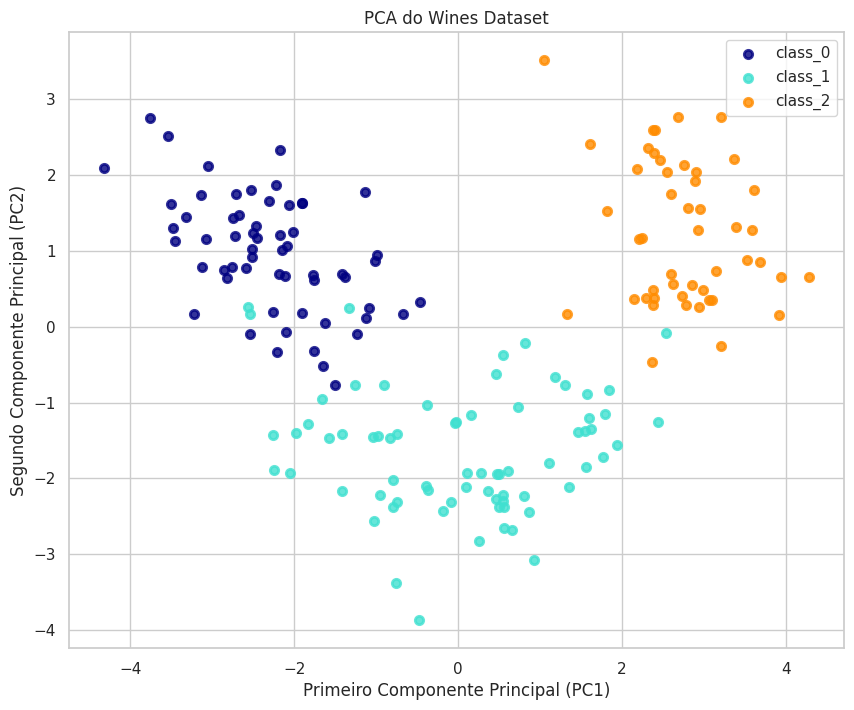

In [49]:
plt.figure(figsize=(10, 8))
target_names = wines.target_names
colors = ['navy', 'turquoise', 'darkorange']

# Plotar cada classe separadamente para criar a legenda
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_wine_pca[y_wine == i, 0], X_wine_pca[y_wine == i, 1],
                color=color, alpha=.8, lw=2,
                label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA do Wines Dataset')
plt.xlabel('Primeiro Componente Principal (PC1)')
plt.ylabel('Segundo Componente Principal (PC2)')
plt.grid(True)
plt.show()

# Exercício 2

### Exercício 2: Compressão e Reconstrução com o MNIST

O dataset MNIST é um dos mais famosos em machine learning e consiste em 70.000 imagens em escala de cinza de 28x28 pixels de dígitos manuscritos (0-9). Devido à sua maior dimensão (784 features) e tamanho, ele representa um desafio mais realista para a redução de dimensionalidade. Sua tarefa é investigar a capacidade do PCA de comprimir e reconstruir essas imagens. Carregue o dataset (disponível em várias bibliotecas como `sklearn.datasets.fetch_openml`, `tensorflow.keras.datasets` ou `torchvision.datasets`), aplique o PCA no conjunto de treinamento e, em seguida, use os componentes aprendidos para transformar e reconstruir algumas imagens do conjunto de teste. Finalmente, crie uma visualização comparando as imagens originais com suas versões reconstruídas para avaliar qualitativamente a perda de informação.

In [50]:
from sklearn.datasets import fetch_openml
X_digits, y_digits = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


# Inspecionar as dimensões dos dados
n_samples = 70000
h = 28
w = 28
n_features = X_digits.shape[1]
target_names = y_digits
n_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print("Número total de amostras:", n_samples)
print("Número de características (pixels):", n_features)
print("Número de classes (dígitos):", n_classes)
print("Dimensões de cada imagem: {} x {}".format(h, w))

Número total de amostras: 70000
Número de características (pixels): 784
Número de classes (dígitos): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Dimensões de cada imagem: 28 x 28


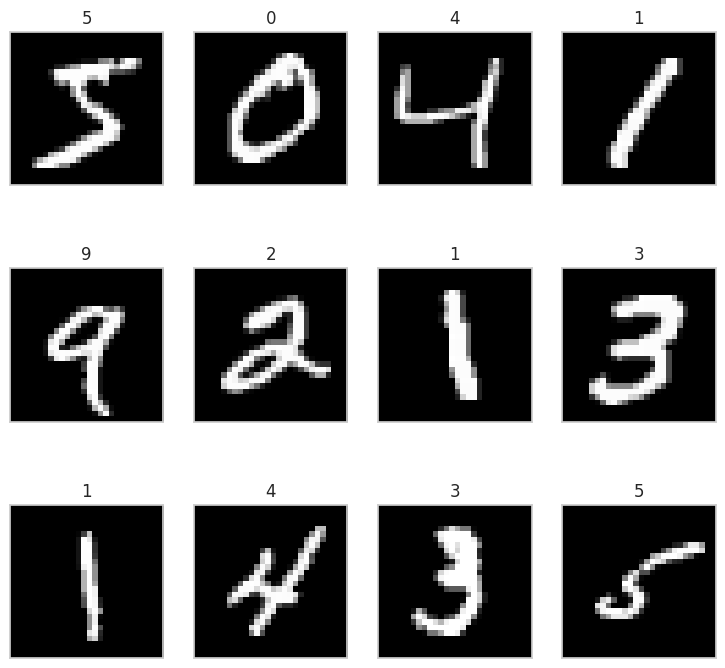

In [51]:
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

# Plotar a primeira galeria
sample_titles = [y_digits[i] for i in range(12)]
plot_gallery(X_digits, sample_titles, h, w)

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.25, random_state=42)

n_components = 150
pca_digits = PCA(n_components=n_components)
pca_digits.fit(X_train)

print(f"PCA ajustado. {n_components} componentes principais foram extraídos de {n_features} características.")

PCA ajustado. 150 componentes principais foram extraídos de 784 características.


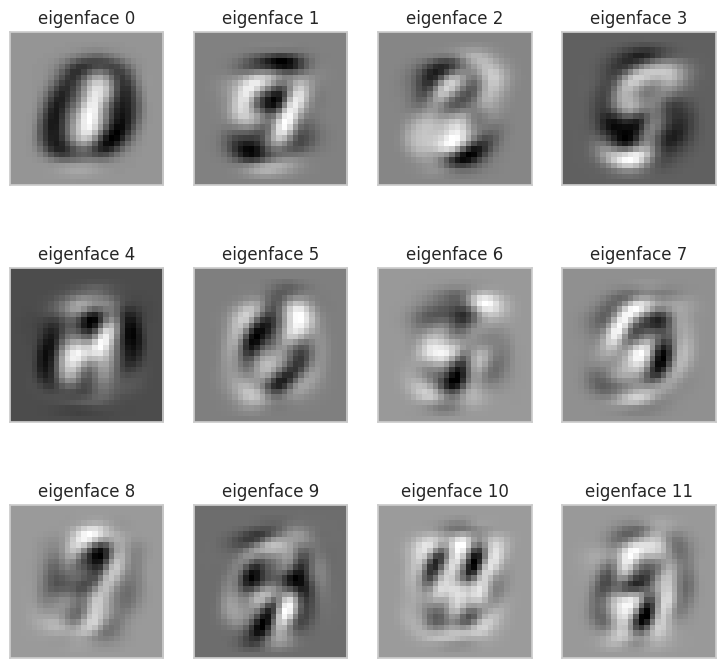

In [53]:
# As eigenfaces são os componentes armazenados no objeto PCA
eigendigits = pca_digits.components.real.reshape((n_components, h, w))

eigenface_titles = ["eigenface %d" % i for i in range(eigendigits.shape[0])]
plot_gallery(eigendigits, eigenface_titles, h, w)

In [54]:
# Projetar os dados de teste no subespaço das eigenfaces
X_test_pca = pca_digits.transform(X_test)

# Reconstruir as imagens a partir da representação de baixa dimensão
# Reconstrução = (Projeção @ Componentes) + Média
X_test_reconstructed = np.dot(X_test_pca, pca_digits.components) + pca_digits.mean

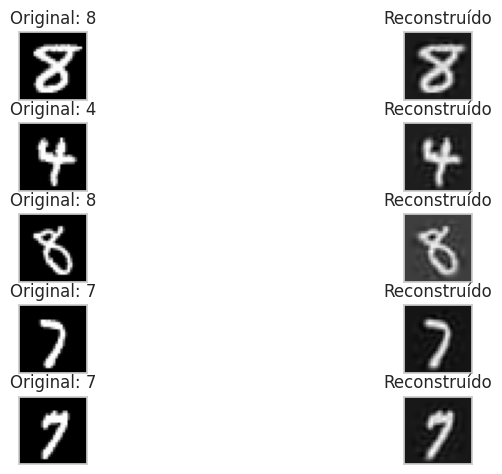

In [55]:
def plot_reconstructions(original, reconstructed, titles, h, w):
    n_images = len(original)
    plt.figure(figsize=(1.8 * 4, 2.4 * (n_images // 2)))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)

    for i in range(n_images):
        # Plot Original
        plt.subplot(n_images, 2, 2*i + 1)
        plt.imshow(original[i].real.reshape((h, w)), cmap=plt.cm.gray)
        plt.title("Original: " + titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

        # Plot Reconstruído
        plt.subplot(n_images, 2, 2*i + 2)
        plt.imshow(reconstructed[i].real.reshape((h, w)), cmap=plt.cm.gray)
        plt.title("Reconstruído", size=12)
        plt.xticks(())
        plt.yticks(())

# Selecionar 5 imagens de teste para visualização
n_comparisons = 5
test_titles = [y_test[i] for i in range(n_comparisons)]
plot_reconstructions(X_test[:n_comparisons], X_test_reconstructed[:n_comparisons], test_titles, h, w)

# Avaliando qualitativamente o resultado do PCA:
Observamos na reconstrução que a redução de qualidade é mínima comparada à redução da dimensionalidade de 784 features para 150.